In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data,
                    columns=housing.feature_names)
data["Price"] = housing.target

In [35]:
x = data[['AveRooms']].values
y = data['Price'].values
data.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

In [36]:
data.shape

(20640, 9)

In [37]:
x_train, x_test, y_train, ytest=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [38]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [49]:
w=0
b=0

learning_rate=0.01
epochs = 1000
cost_history=[]
n=len(x_train_scaled)

for i in range(epochs):
    y_pred=w*x_train_scaled.flatten()+b
    dw=(1/n)*np.sum((y_pred-y_train)*x_train_scaled.flatten())
    db=(1/n)*np.sum(y_pred-y_train)
    w=w-learning_rate*dw
    b=b-learning_rate*db
    cost = (1/(2*n)) * np.sum((y_pred - y_train) **2)
    cost_history.append(cost)
    if i % 100 ==0:
        
        print(f"Epoch {i}, Cost +{cost:.4f}")

y_pred_gd = w* x_test_scaled.flatten()+b

Epoch 0, Cost +2.8149
Epoch 100, Cost +0.9414
Epoch 200, Cost +0.6904
Epoch 300, Cost +0.6568
Epoch 400, Cost +0.6523
Epoch 500, Cost +0.6517
Epoch 600, Cost +0.6516
Epoch 700, Cost +0.6516
Epoch 800, Cost +0.6516
Epoch 900, Cost +0.6516


In [40]:
print("Gradient Descent")
print("-----------------")
print("Weight :", w)
print("Bias :",b)
print("MSE:", mean_squared_error(ytest, y_pred_gd))
print("R2 Score:", r2_score(ytest,y_pred_gd))

Gradient Descent
-----------------
Weight : 0.18323090648660517
Bias : 2.0718574888450205
MSE: 1.292327655590046
R2 Score: 0.013798228607320828


In [41]:
x_train_ne = np.c_[np.ones((len(x_train),1)),x_train]
x_test_ne = np.c_[np.ones((len(x_test),1)),x_test]
theta = np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne.T @ y_train
y_pred_ne= x_test_ne @ theta

In [42]:
print("\nNormal Equation")
print("-----------------")
print("Intercept :", theta[0])
print("Slope :",theta[1])
print("MSE:", mean_squared_error(ytest, y_pred_ne))
print("R2 Score:", r2_score(ytest,y_pred_ne))


Normal Equation
-----------------
Intercept : 1.6547622685968417
Slope : 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


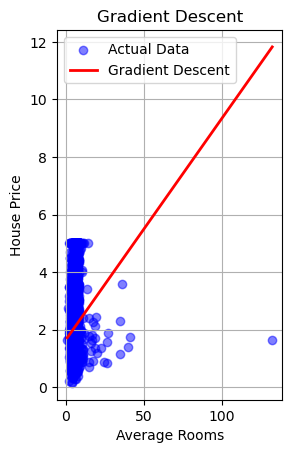

In [43]:
plt.subplot(1, 2, 1)

# Scatter plot of actual test data
plt.scatter(x_test, ytest, color='blue', alpha=0.5, label='Actual Data')

# Sort values so the regression line is drawn correctly
sorted_idx = np.argsort(x_test.flatten())

plt.plot(
    x_test.flatten()[sorted_idx],
    y_pred_gd[sorted_idx],
    color='red',
    linewidth=2,
    label='Gradient Descent'
)

plt.xlabel("Average Rooms")
plt.ylabel("House Price")
plt.title("Gradient Descent")
plt.legend()
plt.grid(True)



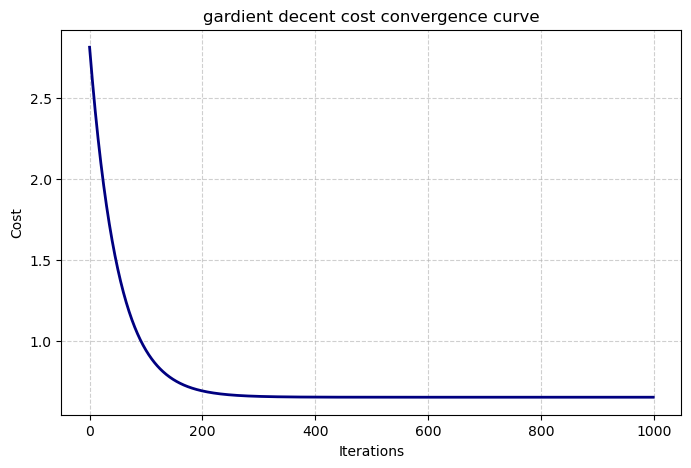

In [51]:
plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)
plt.title("gardient decent cost convergence curve")
plt.grid(True,linestyle='--',alpha=0.6)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

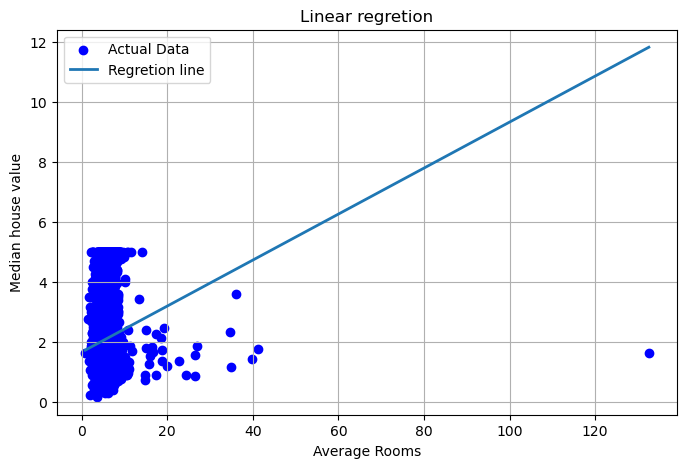

In [48]:
index = np.argsort(x_test.flatten())

plt.figure(figsize=(8, 5))

# Actual data
plt.scatter(x_test, ytest, color='blue', label='Actual Data')

# Regression line
plt.plot(
    x_test.flatten()[index],
    y_pred_ne[index],
    
    linewidth=2,
    label='Regretion line'
)

plt.title("Linear regretion")
plt.xlabel("Average Rooms")
plt.ylabel("Median house value")

plt.legend()
plt.grid(True)
plt.show()

